In [3]:
BRANCH = "vasily/add-visualization"
!git clone --branch {BRANCH} https://github.com/Eroouu/DL_project.git
%cd DL_project

Cloning into 'DL_project'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 124 (delta 51), reused 105 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (124/124), 472.98 KiB | 5.84 MiB/s, done.
Resolving deltas: 100% (51/51), done.
/content/DL_project/DL_project


In [4]:
!nvidia-smi

Mon May 25 17:00:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
!pip install -q torch torchvision pandas numpy pyyaml pillow scikit-learn matplotlib gdown

In [1]:
!mkdir -p /content/acdc_drive

!gdown --folder https://drive.google.com/drive/folders/12NlXg98cZCXSPuspHE7PhXS-7hgTzRS8 \
  -O /content/acdc_drive

Retrieving folder contents
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Download completed


In [6]:
!find /content/acdc_drive -maxdepth 5 -type f -printf "%p  %k KB\n"

In [7]:
import os

os.environ["KAGGLE_API_TOKEN"] = "YOUR_KAGGLE_API_TOKEN"

!mkdir -p /content/acdc_kaggle
!kaggle datasets download -d qweewqer/acdc-file -p /content/acdc_kaggle --force

!ls -lh /content/acdc_kaggle

Dataset URL: https://www.kaggle.com/datasets/qweewqer/acdc-file
License(s): MIT
100% 15.7G/15.7G [01:31<00:00, 184MB/s]

total 16G
-rw-r--r-- 1 root root 16G May 25 16:38 acdc-file.zip


In [9]:
!mkdir -p /content/acdc_kaggle/unpacked
!unzip -q /content/acdc_kaggle/acdc-file.zip -d /content/acdc_kaggle/unpacked

!ls -lh /content/acdc_kaggle/unpacked

total 8.0K
drwxr-xr-x 3 root root 4.0K May 25 17:03 gt_trainval
drwxr-xr-x 3 root root 4.0K May 25 17:03 rgb_anon_trainvaltest


In [10]:
!find /content/acdc_kaggle/unpacked -maxdepth 3 -type d | head -50
!find /content/acdc_kaggle/unpacked/gt_trainval/gt -name "*_gt_labelTrainIds.png" | head
!find /content/acdc_kaggle/unpacked/rgb_anon_trainvaltest/rgb_anon -name "*_rgb_anon.png" | head

/content/acdc_kaggle/unpacked
/content/acdc_kaggle/unpacked/rgb_anon_trainvaltest
/content/acdc_kaggle/unpacked/rgb_anon_trainvaltest/rgb_anon
/content/acdc_kaggle/unpacked/rgb_anon_trainvaltest/rgb_anon/rain
/content/acdc_kaggle/unpacked/rgb_anon_trainvaltest/rgb_anon/snow
/content/acdc_kaggle/unpacked/rgb_anon_trainvaltest/rgb_anon/night
/content/acdc_kaggle/unpacked/rgb_anon_trainvaltest/rgb_anon/fog
/content/acdc_kaggle/unpacked/gt_trainval
/content/acdc_kaggle/unpacked/gt_trainval/gt
/content/acdc_kaggle/unpacked/gt_trainval/gt/rain
/content/acdc_kaggle/unpacked/gt_trainval/gt/snow
/content/acdc_kaggle/unpacked/gt_trainval/gt/night
/content/acdc_kaggle/unpacked/gt_trainval/gt/fog
/content/acdc_kaggle/unpacked/gt_trainval/gt/rain/train/GOPR0402/GOPR0402_frame_000984_gt_labelTrainIds.png
/content/acdc_kaggle/unpacked/gt_trainval/gt/rain/train/GOPR0402/GOPR0402_frame_000958_gt_labelTrainIds.png
/content/acdc_kaggle/unpacked/gt_trainval/gt/rain/train/GOPR0402/GOPR0402_frame_000531_gt_

In [11]:
%cd /content/DL_project
!pip install -q torch torchvision pandas numpy pyyaml pillow scikit-learn matplotlib

/content/DL_project


In [12]:
!python src/dataset_builder.py \
  --data-root /content/acdc_kaggle/unpacked \
  --classmap configs/classmap.json \
  --out-dir metadata \
  --prefix metadata

Built 2006 labeled rows
train: metadata/metadata_train.csv
val: metadata/metadata_val.csv
test: metadata/metadata_test.csv
all: metadata/metadata_all.csv


In [13]:
!python scripts/validate_data_contract.py \
  --metadata-dir metadata \
  --classmap configs/classmap.json

metadata/metadata_train.csv: ok | rows=1280 | object_columns=18 | weather=['fog', 'night', 'rain', 'snow']
metadata/metadata_val.csv: ok | rows=320 | object_columns=18 | weather=['fog', 'night', 'rain', 'snow']


In [14]:
!python scripts/train.py \
  --config configs/resnet50_smoke.yaml \
  --metadata-dir metadata \
  --output-dir checkpoints \
  --device auto

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:00<00:00, 181MB/s]
Training config:
{
  "metadata_dir": "metadata",
  "model_name": "resnet50",
  "batch_size": "8",
  "lr": "0.001",
  "weight_decay": "0.0001",
  "epochs": "1",
  "image_size": "224",
  "num_workers": "2",
  "output_dir": "checkpoints",
  "hidden_dim": "256",
  "dropout": "0.1",
  "freeze_backbone": "True",
  "pretrained_backbone": "True",
  "weather_loss_weight": "1.0",
  "object_loss_weight": "1.0",
  "limit_train": "64",
  "limit_val": "32",
  "device": "auto",
  "seed": "42",
  "image_root": "None"
}
Train samples: 64 | Val samples: 32 | Device: cuda
epoch 01 | train total=1.7845, weather=1.2120, objects=0.5725 | val total=1.5108, weather=1.0552, objects=0.4556
saved checkpoint: checkpoints/resnet50_epoch01.pt


In [16]:
!python - <<'PY'
from pathlib import Path

path = Path("scripts/predict.py")
text = path.read_text()

old = 'checkpoint = torch.load(args.checkpoint, map_location="cpu")'
new = 'checkpoint = torch.load(args.checkpoint, map_location="cpu", weights_only=False)'

assert old in text, "Expected torch.load line not found"
path.write_text(text.replace(old, new))

print("patched scripts/predict.py")
PY

/bin/bash: line 1: warning: here-document at line 1 delimited by end-of-file (wanted `PY')
patched scripts/predict.py


NameError: name 'PY' is not defined

In [17]:
!grep -n "torch.load" scripts/predict.py

38:    checkpoint = torch.load(args.checkpoint, map_location="cpu", weights_only=False)


In [18]:
!python scripts/predict.py \
  --checkpoint checkpoints/resnet50_epoch01.pt \
  --metadata-dir metadata \
  --out artifacts/predictions/resnet50_smoke_val.npz \
  --device auto

Saved predictions to artifacts/predictions/resnet50_smoke_val.npz
{
  "samples": 320,
  "label_columns": [
    "has_sidewalk",
    "has_building",
    "has_wall",
    "has_fence",
    "has_pole",
    "has_traffic_light",
    "has_traffic_sign",
    "has_vegetation",
    "has_terrain",
    "has_sky",
    "has_person",
    "has_rider",
    "has_car",
    "has_truck",
    "has_bus",
    "has_train",
    "has_motorcycle",
    "has_bicycle"
  ]
}


In [19]:
!python src/eval.py \
  --metadata metadata/metadata_val.csv \
  --predictions artifacts/predictions/resnet50_smoke_val.npz \
  --class-map configs/classmap.json \
  --tune-thresholds \
  --out reports/metrics/resnet50_smoke_val.json


Evaluation summary
------------------
Samples: 320
Weather accuracy: 0.6875
Weather macro F1: 0.6180
Object mAP: 0.6233
Object macro F1: 0.6692
Object Hamming loss: 0.2602

Per-class object F1
- sidewalk: 0.9244
- building: 0.9404
- wall: 0.7692
- fence: 0.7621
- pole: 0.9984
- traffic_light: 0.6694
- traffic_sign: 0.9644
- vegetation: 0.9921
- terrain: 0.7045
- sky: 1.0000
- person: 0.6174
- rider: 0.2381
- car: 0.9841
- truck: 0.3812
- bus: 0.2444
- train: 0.3579
- motorcycle: 0.2151
- bicycle: 0.2830
Saved evaluation metrics to reports/metrics/resnet50_smoke_val.json


In [20]:
!python src/visualize.py \
  --metrics reports/metrics/resnet50_smoke_val.json \
  --out-dir reports/figures

Saved figures:
- reports/figures/resnet50_smoke_val_weather_confusion.png
- reports/figures/resnet50_smoke_val_object_f1_ap.png
- reports/figures/resnet50_smoke_val_per_weather.png


In [21]:
!ls -lh reports/figures
!ls -lh reports/metrics
!ls -lh artifacts/predictions

total 196K
-rw-r--r-- 1 root root 89K May 25 17:13 resnet50_smoke_val_object_f1_ap.png
-rw-r--r-- 1 root root 40K May 25 17:13 resnet50_smoke_val_per_weather.png
-rw-r--r-- 1 root root 63K May 25 17:13 resnet50_smoke_val_weather_confusion.png
total 36K
-rw-r--r-- 1 root root  24K May 25 17:12 resnet50_smoke_val.json
-rw-r--r-- 1 root root 1.4K May 25 17:12 resnet50_smoke_val.per_class.csv
-rw-r--r-- 1 root root  334 May 25 17:12 resnet50_smoke_val.per_weather.csv
-rw-r--r-- 1 root root  432 May 25 17:12 resnet50_smoke_val.summary.md
total 56K
-rw-r--r-- 1 root root 55K May 25 17:12 resnet50_smoke_val.npz


In [22]:
!python scripts/train.py \
  --config configs/resnet50_full.yaml \
  --metadata-dir metadata \
  --output-dir checkpoints \
  --device auto

Training config:
{
  "metadata_dir": "metadata",
  "model_name": "resnet50",
  "batch_size": "16",
  "lr": "0.001",
  "weight_decay": "0.0001",
  "epochs": "5",
  "image_size": "224",
  "num_workers": "2",
  "output_dir": "checkpoints",
  "hidden_dim": "256",
  "dropout": "0.1",
  "freeze_backbone": "True",
  "pretrained_backbone": "True",
  "weather_loss_weight": "1.0",
  "object_loss_weight": "1.0",
  "device": "auto",
  "seed": "42",
  "image_root": "None"
}
Train samples: 1280 | Val samples: 320 | Device: cuda
epoch 01 | train total=0.7653, weather=0.3835, objects=0.3818 | val total=0.4728, weather=0.1429, objects=0.3298
saved checkpoint: checkpoints/resnet50_epoch01.pt
epoch 02 | train total=0.4145, weather=0.0921, objects=0.3225 | val total=0.4021, weather=0.0855, objects=0.3166
saved checkpoint: checkpoints/resnet50_epoch02.pt
epoch 03 | train total=0.3630, weather=0.0564, objects=0.3066 | val total=0.3953, weather=0.0838, objects=0.3115
saved checkpoint: checkpoints/resnet50_ep

In [23]:
!python scripts/predict.py \
  --checkpoint checkpoints/resnet50_epoch05.pt \
  --metadata-dir metadata \
  --out artifacts/predictions/resnet50_full_val.npz \
  --device auto

Saved predictions to artifacts/predictions/resnet50_full_val.npz
{
  "samples": 320,
  "label_columns": [
    "has_sidewalk",
    "has_building",
    "has_wall",
    "has_fence",
    "has_pole",
    "has_traffic_light",
    "has_traffic_sign",
    "has_vegetation",
    "has_terrain",
    "has_sky",
    "has_person",
    "has_rider",
    "has_car",
    "has_truck",
    "has_bus",
    "has_train",
    "has_motorcycle",
    "has_bicycle"
  ]
}


In [24]:
!python src/eval.py \
  --metadata metadata/metadata_val.csv \
  --predictions artifacts/predictions/resnet50_full_val.npz \
  --class-map configs/classmap.json \
  --tune-thresholds \
  --out reports/metrics/resnet50_full_val.json


Evaluation summary
------------------
Samples: 320
Weather accuracy: 0.9875
Weather macro F1: 0.9875
Object mAP: 0.7280
Object macro F1: 0.7276
Object Hamming loss: 0.1707

Per-class object F1
- sidewalk: 0.9631
- building: 0.9807
- wall: 0.7932
- fence: 0.7696
- pole: 0.9984
- traffic_light: 0.7204
- traffic_sign: 0.9672
- vegetation: 0.9921
- terrain: 0.7442
- sky: 1.0000
- person: 0.6772
- rider: 0.4587
- car: 0.9841
- truck: 0.5310
- bus: 0.2857
- train: 0.5294
- motorcycle: 0.3077
- bicycle: 0.3946
Saved evaluation metrics to reports/metrics/resnet50_full_val.json


In [25]:
!python src/visualize.py \
  --metrics reports/metrics/resnet50_full_val.json \
  --out-dir reports/figures

Saved figures:
- reports/figures/resnet50_full_val_weather_confusion.png
- reports/figures/resnet50_full_val_object_f1_ap.png
- reports/figures/resnet50_full_val_per_weather.png


In [27]:
!ls -lh checkpoints
!ls -lh reports/metrics
!ls -lh reports/figures
!ls -lh artifacts/predictions

total 511M
-rw-r--r-- 1 root root 103M May 25 17:14 resnet50_epoch01.pt
-rw-r--r-- 1 root root 103M May 25 17:15 resnet50_epoch02.pt
-rw-r--r-- 1 root root 103M May 25 17:16 resnet50_epoch03.pt
-rw-r--r-- 1 root root 103M May 25 17:17 resnet50_epoch04.pt
-rw-r--r-- 1 root root 103M May 25 17:18 resnet50_epoch05.pt
total 76K
-rw-r--r-- 1 root root  25K May 25 17:18 resnet50_full_val.json
-rw-r--r-- 1 root root 1.7K May 25 17:18 resnet50_full_val.per_class.csv
-rw-r--r-- 1 root root  323 May 25 17:18 resnet50_full_val.per_weather.csv
-rw-r--r-- 1 root root  430 May 25 17:18 resnet50_full_val.summary.md
-rw-r--r-- 1 root root  24K May 25 17:12 resnet50_smoke_val.json
-rw-r--r-- 1 root root 1.4K May 25 17:12 resnet50_smoke_val.per_class.csv
-rw-r--r-- 1 root root  334 May 25 17:12 resnet50_smoke_val.per_weather.csv
-rw-r--r-- 1 root root  432 May 25 17:12 resnet50_smoke_val.summary.md
total 392K
-rw-r--r-- 1 root root 89K May 25 17:18 resnet50_full_val_object_f1_ap.png
-rw-r--r-- 1 root ro

In [28]:
!zip -r resnet50_outputs.zip \
  checkpoints \
  reports/metrics \
  reports/figures \
  artifacts/predictions \
  metadata \
  configs/resnet50_smoke.yaml \
  configs/resnet50_full.yaml \
  configs/classmap.json \
  RUN_INFO.txt

	zip warning: name not matched: RUN_INFO.txt
  adding: checkpoints/ (stored 0%)
  adding: checkpoints/resnet50_epoch05.pt (deflated 7%)
  adding: checkpoints/resnet50_epoch02.pt (deflated 7%)
  adding: checkpoints/resnet50_epoch01.pt (deflated 7%)
  adding: checkpoints/resnet50_epoch04.pt (deflated 7%)
  adding: checkpoints/resnet50_epoch03.pt (deflated 7%)
  adding: reports/metrics/ (stored 0%)
  adding: reports/metrics/resnet50_smoke_val.per_class.csv (deflated 51%)
  adding: reports/metrics/resnet50_smoke_val.json (deflated 85%)
  adding: reports/metrics/resnet50_full_val.json (deflated 85%)
  adding: reports/metrics/resnet50_smoke_val.per_weather.csv (deflated 39%)
  adding: reports/metrics/resnet50_full_val.summary.md (deflated 46%)
  adding: reports/metrics/resnet50_smoke_val.summary.md (deflated 46%)
  adding: reports/metrics/resnet50_full_val.per_weather.csv (deflated 38%)
  adding: reports/metrics/resnet50_full_val.per_class.csv (deflated 52%)
  adding: reports/figures/ (store

In [29]:
from google.colab import files
files.download("resnet50_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

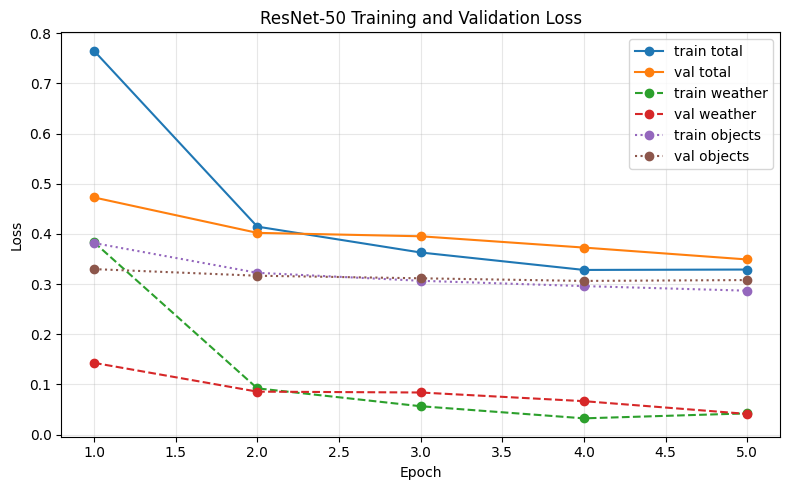

In [30]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ckpt = torch.load("checkpoints/resnet50_epoch05.pt", map_location="cpu", weights_only=False)
history = pd.DataFrame(ckpt["history"])

Path("reports/figures").mkdir(parents=True, exist_ok=True)
Path("reports/metrics").mkdir(parents=True, exist_ok=True)

history.to_csv("reports/metrics/resnet50_full_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_total_loss"], marker="o", label="train total")
plt.plot(history["epoch"], history["val_total_loss"], marker="o", label="val total")
plt.plot(history["epoch"], history["train_weather_loss"], marker="o", linestyle="--", label="train weather")
plt.plot(history["epoch"], history["val_weather_loss"], marker="o", linestyle="--", label="val weather")
plt.plot(history["epoch"], history["train_object_loss"], marker="o", linestyle=":", label="train objects")
plt.plot(history["epoch"], history["val_object_loss"], marker="o", linestyle=":", label="val objects")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-50 Training and Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/resnet50_full_loss_curves.png", dpi=200)
plt.show()

In [31]:
import pandas as pd

per_weather = pd.read_csv("reports/metrics/resnet50_full_val.per_weather.csv")
per_class = pd.read_csv("reports/metrics/resnet50_full_val.per_class.csv")

display(per_weather)
display(per_class.sort_values("average_precision", ascending=False))

,weather,num_samples,object_mAP,object_macro_f1,object_hamming_loss
0,fog,80,0.760649,0.730313,0.122917
1,night,80,0.687864,0.671899,0.241667
2,rain,80,0.727839,0.698261,0.155556
3,snow,80,0.702633,0.685510,0.162500


,class,precision,recall,f1,support,average_precision,threshold
9,sky,1.000000,1.000000,1.000000,320,1.000000,0.05
4,pole,0.996875,1.000000,0.998435,319,0.999681,0.05
7,vegetation,0.984375,1.000000,0.992126,315,0.998843,0.05
1,building,0.978947,0.982394,0.980668,284,0.996876,0.65
12,car,0.968750,1.000000,0.984127,310,0.992808,0.05
0,sidewalk,0.931973,0.996364,0.963093,275,0.989021,0.60
6,traffic_sign,0.945513,0.989933,0.967213,298,0.975787,0.70
2,wall,0.691450,0.930000,0.793177,200,0.827710,0.40
8,terrain,0.752941,0.735632,0.744186,174,0.813429,0.45
5,traffic_light,0.605932,0.888199,0.720403,161,0.811939,0.35


In [32]:
per_class_ap = per_class.sort_values("average_precision", ascending=False)
per_class_ap.to_csv("reports/metrics/resnet50_full_val.per_class_sorted_by_ap.csv", index=False)

display(per_class_ap)

,class,precision,recall,f1,support,average_precision,threshold
9,sky,1.000000,1.000000,1.000000,320,1.000000,0.05
4,pole,0.996875,1.000000,0.998435,319,0.999681,0.05
7,vegetation,0.984375,1.000000,0.992126,315,0.998843,0.05
1,building,0.978947,0.982394,0.980668,284,0.996876,0.65
12,car,0.968750,1.000000,0.984127,310,0.992808,0.05
0,sidewalk,0.931973,0.996364,0.963093,275,0.989021,0.60
6,traffic_sign,0.945513,0.989933,0.967213,298,0.975787,0.70
2,wall,0.691450,0.930000,0.793177,200,0.827710,0.40
8,terrain,0.752941,0.735632,0.744186,174,0.813429,0.45
5,traffic_light,0.605932,0.888199,0.720403,161,0.811939,0.35


In [35]:
map_col = None
for col in per_weather.columns:
    if "map" in col.lower():
        map_col = col
        break

print("mAP column:", map_col)

per_weather_sorted = per_weather.sort_values(map_col, ascending=True)
per_weather_sorted.to_csv("reports/metrics/resnet50_full_val.per_weather_sorted_by_map.csv", index=False)

display(per_weather_sorted)

mAP column: object_mAP


,weather,num_samples,object_mAP,object_macro_f1,object_hamming_loss
1,night,80,0.687864,0.671899,0.241667
3,snow,80,0.702633,0.685510,0.162500
2,rain,80,0.727839,0.698261,0.155556
0,fog,80,0.760649,0.730313,0.122917


In [36]:
per_class = pd.read_csv("reports/metrics/resnet50_full_val.per_class.csv")
print(per_class.columns.tolist())
display(per_class.head())

['class', 'precision', 'recall', 'f1', 'support', 'average_precision', 'threshold']


,class,precision,recall,f1,support,average_precision,threshold
0,sidewalk,0.931973,0.996364,0.963093,275,0.989021,0.60
1,building,0.978947,0.982394,0.980668,284,0.996876,0.65
2,wall,0.691450,0.930000,0.793177,200,0.827710,0.40
3,fence,0.659420,0.923858,0.769556,197,0.756241,0.45
4,pole,0.996875,1.000000,0.998435,319,0.999681,0.05


In [37]:
ap_col = None
for col in per_class.columns:
    if "average_precision" in col.lower() or col.lower() == "ap":
        ap_col = col
        break

print("AP column:", ap_col)

per_class_ap = per_class.sort_values(ap_col, ascending=False)
per_class_ap.to_csv("reports/metrics/resnet50_full_val.per_class_sorted_by_ap.csv", index=False)

display(per_class_ap)

AP column: average_precision


,class,precision,recall,f1,support,average_precision,threshold
9,sky,1.000000,1.000000,1.000000,320,1.000000,0.05
4,pole,0.996875,1.000000,0.998435,319,0.999681,0.05
7,vegetation,0.984375,1.000000,0.992126,315,0.998843,0.05
1,building,0.978947,0.982394,0.980668,284,0.996876,0.65
12,car,0.968750,1.000000,0.984127,310,0.992808,0.05
0,sidewalk,0.931973,0.996364,0.963093,275,0.989021,0.60
6,traffic_sign,0.945513,0.989933,0.967213,298,0.975787,0.70
2,wall,0.691450,0.930000,0.793177,200,0.827710,0.40
8,terrain,0.752941,0.735632,0.744186,174,0.813429,0.45
5,traffic_light,0.605932,0.888199,0.720403,161,0.811939,0.35


In [38]:
!zip -r resnet50_key_tables.zip \
  reports/metrics/resnet50_full_val.per_weather.csv \
  reports/metrics/resnet50_full_val.per_weather_sorted_by_map.csv \
  reports/metrics/resnet50_full_val.per_class.csv \
  reports/metrics/resnet50_full_val.per_class_sorted_by_ap.csv \
  reports/metrics/resnet50_full_val.summary.md \
  reports/metrics/resnet50_full_val.json

  adding: reports/metrics/resnet50_full_val.per_weather.csv (deflated 38%)
  adding: reports/metrics/resnet50_full_val.per_weather_sorted_by_map.csv (deflated 39%)
  adding: reports/metrics/resnet50_full_val.per_class.csv (deflated 52%)
  adding: reports/metrics/resnet50_full_val.per_class_sorted_by_ap.csv (deflated 51%)
  adding: reports/metrics/resnet50_full_val.summary.md (deflated 46%)
  adding: reports/metrics/resnet50_full_val.json (deflated 85%)


In [39]:
from google.colab import files
files.download("resnet50_key_tables.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
!zip -r resnet50_final_light.zip \
  reports/metrics/resnet50_full_val.summary.md \
  reports/metrics/resnet50_full_val.json \
  reports/metrics/resnet50_full_val.per_class.csv \
  reports/metrics/resnet50_full_val.per_class_sorted_by_ap.csv \
  reports/metrics/resnet50_full_val.per_weather.csv \
  reports/metrics/resnet50_full_val.per_weather_sorted_by_map.csv \
  reports/metrics/resnet50_full_history.csv \
  reports/figures/resnet50_full_loss_curves.png \
  reports/figures/resnet50_full_val_weather_confusion.png \
  reports/figures/resnet50_full_val_object_f1_ap.png \
  reports/figures/resnet50_full_val_per_weather.png \
  artifacts/predictions/resnet50_full_val.npz \
  configs/resnet50_full.yaml \
  configs/classmap.json

  adding: reports/metrics/resnet50_full_val.summary.md (deflated 46%)
  adding: reports/metrics/resnet50_full_val.json (deflated 85%)
  adding: reports/metrics/resnet50_full_val.per_class.csv (deflated 52%)
  adding: reports/metrics/resnet50_full_val.per_class_sorted_by_ap.csv (deflated 51%)
  adding: reports/metrics/resnet50_full_val.per_weather.csv (deflated 38%)
  adding: reports/metrics/resnet50_full_val.per_weather_sorted_by_map.csv (deflated 39%)
  adding: reports/metrics/resnet50_full_history.csv (deflated 49%)
  adding: reports/figures/resnet50_full_loss_curves.png (deflated 9%)
  adding: reports/figures/resnet50_full_val_weather_confusion.png (deflated 20%)
  adding: reports/figures/resnet50_full_val_object_f1_ap.png (deflated 20%)
  adding: reports/figures/resnet50_full_val_per_weather.png (deflated 27%)
  adding: artifacts/predictions/resnet50_full_val.npz (deflated 49%)
  adding: configs/resnet50_full.yaml (deflated 36%)
  adding: configs/classmap.json (deflated 69%)


In [42]:
from google.colab import files
files.download("resnet50_final_light.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>